In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Update this path to your actual CSV location
df = pd.read_csv("/Users/vittoriobariosco/Documents/APPLICATIONS/MIGx/COVID_clinical_Trials.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")




Dataset loaded: 5,783 rows × 27 columns


## 1. Dataset Overview

**Source:** ClinicalTrials.gov — COVID-19 Clinical Trials Dataset (Kaggle)  
**Extraction date:** 2026  
**Total trials:** 5,783  
**Total columns:** 27  

This dataset contains clinical trials related to COVID-19 registered on 
ClinicalTrials.gov. Data was extracted from public registry records.

                         missing_count  missing_pct
Phases                            2461         42.6
Locations                          585         10.1
Start Date                          34          0.6
Study Designs                       35          0.6
Enrollment                          34          0.6
Completion Date                     36          0.6
Primary Completion Date             36          0.6
Status                               0          0.0
Conditions                           0          0.0
Funded Bys                           0          0.0
Study Type                           0          0.0


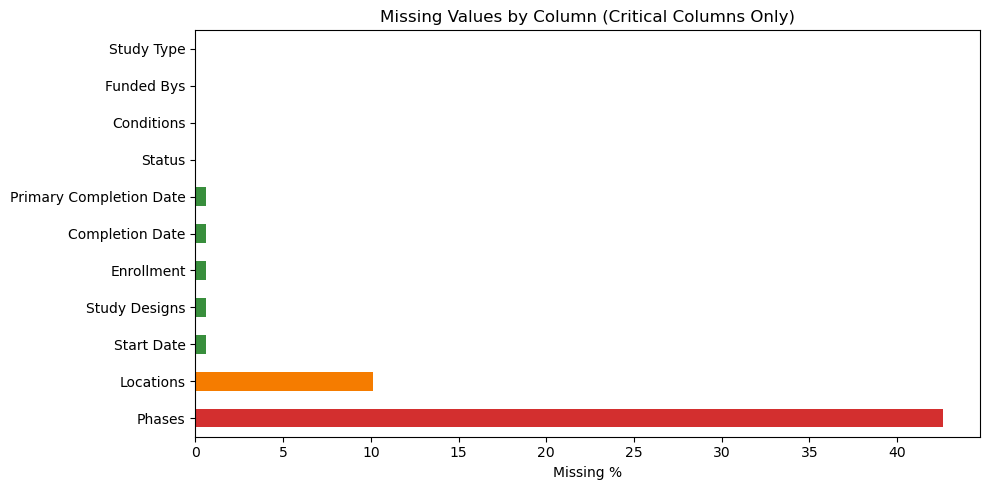

In [66]:
critical_columns = [
    'Phases', 'Status', 'Conditions', 'Start Date',
    'Funded Bys', 'Study Type', 'Study Designs',
    'Enrollment', 'Locations', 'Completion Date',
    'Primary Completion Date'
]

missing = pd.DataFrame({
    'missing_count': df[critical_columns].isnull().sum(),
    'missing_pct':   (df[critical_columns].isnull().sum() / len(df) * 100).round(1)
}).sort_values('missing_pct', ascending=False)

print(missing)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d32f2f' if x > 20 else '#f57c00' if x > 5 else '#388e3c' 
          for x in missing['missing_pct']]
missing['missing_pct'].plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column (Critical Columns Only)')
plt.tight_layout()
plt.show()

## 2. Missing Value Analysis

| Column | Missing % | Impact | Decision |
|---|---|---|---|
| `Phases` | 42.6% | High — affects Q1 and Q5 | Label as "Unknown", exclude from phase-specific queries |
| `Locations` | 10.1% | Medium — affects Q4 | Accept loss, document in limitations |
| `Start Date` | 0.6% | Low | Exclude affected rows from duration analysis only |
| `Study Designs` | 0.6% | Low | Accept as-is |
| `Enrollment` | 0.6% | Low | Exclude from enrollment analysis only |
| `Completion Date` | 0.6% | Low | Exclude from duration analysis only |
| `Status` | 0% | None | No action needed |
| `Conditions` | 0% | None | No action needed |

**Key finding:** The `Phases` column has 42.6% missing values — a known 
limitation of self-reported clinical trial registries where phase 
classification is optional. Trials without phase information are retained 
in the database and included in all non-phase analyses, but explicitly 
excluded when phase is the unit of analysis. This limitation is 
acknowledged throughout the analysis.

=== STATUS DISTRIBUTION ===
Status
Recruiting                   2805
Completed                    1025
Not yet recruiting           1004
Active, not recruiting        526
Enrolling by invitation       181
Withdrawn                     107
Terminated                     74
Suspended                      27
Available                      19
No longer available            12
Approved for marketing          2
Temporarily not available       1
Name: count, dtype: int64

=== STATUS GROUPS ===
status_group
Active       4516
Completed    1025
Stopped       208
Other          34
Name: count, dtype: int64


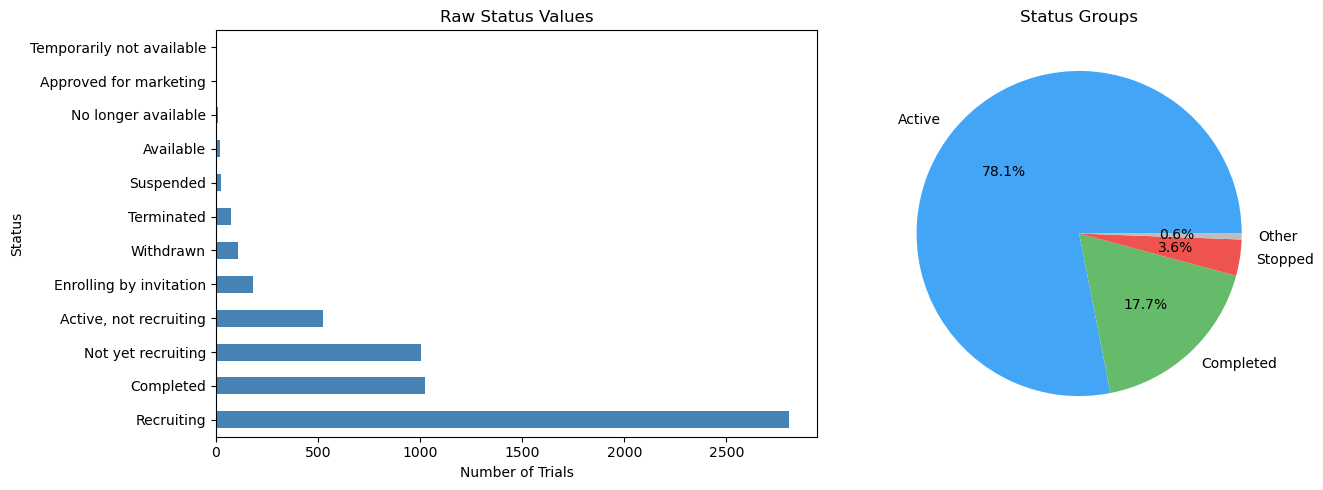

In [67]:
print("=== STATUS DISTRIBUTION ===")
status_counts = df['Status'].value_counts(dropna=False)
print(status_counts)

# Create status groups
def group_status(status):
    if status in ['Recruiting', 'Not yet recruiting', 
                  'Active, not recruiting', 'Enrolling by invitation']:
        return 'Active'
    elif status == 'Completed':
        return 'Completed'
    elif status in ['Withdrawn', 'Terminated', 'Suspended']:
        return 'Stopped'
    else:
        return 'Other'

df['status_group'] = df['Status'].apply(group_status)

print("\n=== STATUS GROUPS ===")
print(df['status_group'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — raw status
status_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Raw Status Values')
axes[0].set_xlabel('Number of Trials')

# Right — grouped
df['status_group'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#42a5f5', '#66bb6a', '#ef5350', '#bdbdbd']
)
axes[1].set_title('Status Groups')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 3. Trial Status Analysis

Status values are clean with no missing values and consistent formatting.
12 distinct values were grouped into 4 analytical categories:

| Group | Statuses Included | Count | % |
|---|---|---|---|
| **Active** | Recruiting, Not yet recruiting, Active not recruiting, Enrolling by invitation | 4,516 | 78.1% |
| **Completed** | Completed | 1,025 | 17.7% |
| **Stopped** | Withdrawn, Terminated, Suspended | 208 | 3.6% |
| **Other** | Available, No longer available, Approved for marketing, Temporarily not available | 34 | 0.6% |

**Key finding:** 78% of trials were still active at time of data extraction 
(2026), reflecting the ongoing nature of COVID-19 research. The 3.6% 
stopped rate (terminated/withdrawn) is the primary focus of Question 2 
(Completion Analysis).

In [68]:
print("=== RAW PHASE VALUES ===")
print(df['Phases'].value_counts(dropna=False))

# Clean phases
def clean_phase(phase):
    if pd.isna(phase):
        return 'Unknown'
    phases = [p.strip() for p in str(phase).split('|')]
    # Define ordering to pick the highest phase
    order = {
        'Early Phase 1': 0,
        'Phase 1': 1,
        'Phase 2': 2,
        'Phase 3': 3,
        'Phase 4': 4,
        'Not Applicable': 5
    }
    # Sort by order and take the last (highest)
    sorted_phases = sorted(phases, key=lambda x: order.get(x, -1))
    return sorted_phases[-1] if sorted_phases else 'Unknown'

df['phase_clean'] = df['Phases'].apply(clean_phase)

print("\n=== CLEANED PHASE VALUES ===")
print(df['phase_clean'].value_counts())

=== RAW PHASE VALUES ===
Phases
NaN                2461
Not Applicable     1354
Phase 2             685
Phase 3             450
Phase 1             234
Phase 2|Phase 3     200
Phase 1|Phase 2     192
Phase 4             161
Early Phase 1        46
Name: count, dtype: int64

=== CLEANED PHASE VALUES ===
phase_clean
Unknown           2461
Not Applicable    1354
Phase 2            877
Phase 3            650
Phase 1            234
Phase 4            161
Early Phase 1       46
Name: count, dtype: int64


## 4. Phase Distribution

**Critical finding:** 42.6% of trials have no phase recorded.

Multi-phase trials (e.g., "Phase 1|Phase 2") were resolved by assigning 
the highest phase reached, reflecting the most advanced stage of development.

| Phase | Count | % of total |
|---|---|---|
| Unknown | 2,461 | 42.6% |
| Not Applicable | 1,354 | 23.4% |
| Phase 2 | 685 | 11.8% |
| Phase 3 | 450 | 7.8% |
| Phase 1 | 234 | 4.0% |
| Phase 4 | 161 | 2.8% |
| Early Phase 1 | 46 | 0.8% |

**Key finding:** "Unknown" trials are retained in the database 
but excluded from phase-specific queries. "Not Applicable" trials are 
observational studies, valid but analytically distinct from 
interventional trials with defined phases.

In [69]:
df['Enrollment'] = pd.to_numeric(df['Enrollment'], errors='coerce')

print("=== ENROLLMENT STATS ===")
print(df['Enrollment'].describe())
print(f"\nMissing:         {df['Enrollment'].isna().sum()}")
print(f"Zero enrollment: {(df['Enrollment'] == 0).sum()}")
print(f"Over 100,000:    {(df['Enrollment'] > 100000).sum()}")

print("\n=== ZERO ENROLLMENT BY STATUS ===")
zero = df[df['Enrollment'] == 0]
print(zero['Status'].value_counts())

print("\n=== ENROLLMENT BY STUDY TYPE ===")
print(df.groupby('Study Type')['Enrollment'].agg(['median', 'mean', 'max']).round(0))

# Check how many records are Expanded Access
expanded = df[df['Study Type'].str.contains('Expanded', na=False)]
print(f"Expanded Access records: {len(expanded)}")
print(f"That's {len(expanded)/len(df)*100:.1f}% of the dataset")

# Remove Expanded Access programs — not clinical trials
# 34 records (0.6%) with no enrollment data and outside scope of analysis
df = df[~df['Study Type'].str.contains('Expanded', na=False)]



=== ENROLLMENT STATS ===
count    5.749000e+03
mean     1.831949e+04
std      4.045437e+05
min      0.000000e+00
25%      6.000000e+01
50%      1.700000e+02
75%      5.600000e+02
max      2.000000e+07
Name: Enrollment, dtype: float64

Missing:         34
Zero enrollment: 107
Over 100,000:    47

=== ZERO ENROLLMENT BY STATUS ===
Status
Withdrawn    107
Name: count, dtype: int64

=== ENROLLMENT BY STUDY TYPE ===
                                                    median     mean  \
Study Type                                                            
Expanded Access                                        NaN      NaN   
Expanded Access:Individual Patients                    NaN      NaN   
Expanded Access:Individual Patients|Intermediat...     NaN      NaN   
Expanded Access:Individual Patients|Treatment I...     NaN      NaN   
Expanded Access:Intermediate-size Population           NaN      NaN   
Expanded Access:Intermediate-size Population|Tr...     NaN      NaN   
Expanded Access:T

## 5. Enrollment Analysis

| Metric | Value |
|---|---|
| Total trials with enrollment data | 5,749 |
| Missing | 34 (0.6%) |
| Median enrollment | 170 participants |
| Mean enrollment | 18,319 participants |
| Maximum | 20,000,000 (observational study) |
| Zero enrollment | 107 trials (all Withdrawn) |
| Over 100,000 | 47 trials |

**Key finding:** The mean (18,319) is 100× larger than the median (170), 
indicating extreme right skew driven by large observational studies. 
The median is the appropriate measure of central tendency for this dataset.

**Observational vs Interventional:**
- Interventional median: 108 participants
- Observational median: 300 participants

Observational studies have systematically higher enrollment as they 
track rather than treat patients. These two study types are analyzed 
separately in all enrollment-related queries.

**Analytical decisions:**
- Zero-enrollment trials (all Withdrawn) excluded from enrollment analysis
- Observational and Interventional trials analyzed separately
- Expanded Access programs, 34 records (0.6%), were excluded
- Median used instead of mean throughout to avoid outlier distortion

In [70]:
#Parse all date columns
for col in ['Start Date', 'Completion Date', 'Primary Completion Date', 
            'Last Update Posted', 'First Posted']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

#Raw date ranges before any cleaning
print("=== RAW DATE RANGES (before cleaning) ===")
for col in ['Start Date', 'Completion Date', 'Primary Completion Date']:
    print(f"\n--- {col} ---")
    print(f"  Valid:   {df[col].notna().sum():,}")
    print(f"  Missing: {df[col].isna().sum():,}")
    print(f"  Min:     {df[col].min().date()}")
    print(f"  Max:     {df[col].max().date()}")

#Determine data-driven cutoff from extraction date
print("\n=== EXTRACTION DATE (from dataset metadata) ===")
extraction_date = df['Last Update Posted'].max()
cutoff = extraction_date + pd.DateOffset(years=10)
print(f"  Extraction date: {extraction_date.date()}")
print(f"  Cutoff date:     {cutoff.date()} (extraction + 10 year buffer)")

#Flag problematic dates
print("\n=== PROBLEMATIC DATES IDENTIFIED ===")
completion_to_null = (df['Completion Date'] > cutoff).sum()
primary_to_null = (df['Primary Completion Date'] > cutoff).sum()
pre_2020 = (df['Start Date'] < '2020-01-01').sum()
pre_2000 = (df['Start Date'] < '2000-01-01').sum()

print(f"  Completion dates beyond cutoff ({cutoff.date()}): {completion_to_null}")
print(f"  Primary completion dates beyond cutoff:           {primary_to_null}")
print(f"  Start dates before 2020 (pre-COVID):              {pre_2020} ({pre_2020/len(df)*100:.1f}%)")
print(f"  Start dates before 2000 (likely errors):          {pre_2000}")

#Apply cleaning
#Set placeholder completion dates to NULL
df.loc[df['Completion Date'] > cutoff, 'Completion Date'] = None
df.loc[df['Primary Completion Date'] > cutoff, 'Primary Completion Date'] = None

#Flag pre-2020 trials (don't delete — just mark)
df['pre_covid_start'] = df['Start Date'] < '2020-01-01'

#Flag the single pre-2000 trial
df['date_error'] = df['Start Date'] < '2000-01-01'

#Verify after cleaning
print("\n=== DATE RANGES AFTER CLEANING ===")
for col in ['Start Date', 'Completion Date', 'Primary Completion Date']:
    print(f"\n--- {col} ---")
    print(f"  Valid:   {df[col].notna().sum():,}")
    print(f"  Missing: {df[col].isna().sum():,}")
    if df[col].notna().any():
        print(f"  Min:     {df[col].min().date()}")
        print(f"  Max:     {df[col].max().date()}")

print(f"\n  Pre-COVID start flag:  {df['pre_covid_start'].sum()} trials")
print(f"  Date error flag:       {df['date_error'].sum()} trials")

=== RAW DATE RANGES (before cleaning) ===

--- Start Date ---
  Valid:   5,263
  Missing: 486
  Min:     1998-01-01
  Max:     2021-12-01

--- Completion Date ---
  Valid:   4,258
  Missing: 1,491
  Min:     2018-05-25
  Max:     2099-12-31

--- Primary Completion Date ---
  Valid:   4,321
  Missing: 1,428
  Min:     2016-05-31
  Max:     2099-12-31

=== EXTRACTION DATE (from dataset metadata) ===
  Extraction date: 2021-04-14
  Cutoff date:     2031-04-14 (extraction + 10 year buffer)

=== PROBLEMATIC DATES IDENTIFIED ===
  Completion dates beyond cutoff (2031-04-14): 10
  Primary completion dates beyond cutoff:           3
  Start dates before 2020 (pre-COVID):              175 (3.0%)
  Start dates before 2000 (likely errors):          1

=== DATE RANGES AFTER CLEANING ===

--- Start Date ---
  Valid:   5,263
  Missing: 486
  Min:     1998-01-01
  Max:     2021-12-01

--- Completion Date ---
  Valid:   4,248
  Missing: 1,501
  Min:     2018-05-25
  Max:     2031-02-23

--- Primary Co

## 6. Date Quality Analysis

### Raw Data Assessment

| Column | Valid | Missing | Earliest | Latest (raw) |
|---|---|---|---|---|
| `Start Date` | 5,263 | 486 (8.4%) | 1998-01-01 | 2021-12-01 |
| `Completion Date` | 4,258 | 1,491 (25.8%) | 2018-05-25 | 2099-12-31 |
| `Primary Completion Date` | 4,321 | 1,428 (24.7%) | 2016-05-31 | 2099-12-31 |

Dataset extraction date confirmed as **2021-04-14** from 
`Last Update Posted` metadata.

---

### Issues Identified & Cleaning Actions

**Issue 1 — Placeholder future dates (2099-12-31)**

Both `Completion Date` and `Primary Completion Date` contained dates 
of 2099-12-31.

**Cleaning approach:** A data-driven cutoff was established rather 
than an arbitrary fixed year:

- Extraction date: **2021-04-14** (verified from `Last Update Posted`)
- Buffer: **+10 years** (maximum realistic clinical trial duration)
- Resulting cutoff: **2031-04-14**

Any completion date beyond this threshold was set to NULL.

**Impact:**
- Completion Date: 10 placeholder dates removed
- Primary Completion Date: 3 placeholder dates removed
- Maximum completion date after cleaning: **2031-02-23** — a 
  legitimate long-running trial registered in 2021
- Zero legitimate future dates were lost, confirming the 10-year 
  buffer was appropriately conservative

| | Before cleaning | After cleaning |
|---|---|---|
| Completion Date valid | 4,258 | 4,248 (-10) |
| Completion Date max | 2099-12-31 | 2031-02-23 |
| Primary Completion valid | 4,321 | 4,318 (-3) |
| Primary Completion max | 2099-12-31 | 2031-02-23 |

---

**Issue 2 — Pre-2020 Start Dates (175 trials, 3.0%)**

COVID-19 emerged in late 2019. Trials with start dates before 2020 
are anomalous in a COVID-focused dataset. Two explanations are 
plausible:

1. **Repurposed trials** — studies originally designed for other 
   conditions that added COVID-19 as an endpoint after the pandemic 
   began. This was a documented and common practice in 2020.
2. **Data entry errors** — incorrect year entered during registration.

Status distribution of these 175 trials supports explanation 1:
- 97 still Recruiting → consistent with long-running repurposed studies
- 38 Completed → plausible for studies that started pre-pandemic
- 34 Active, not recruiting → consistent with ongoing repurposed studies

**Cleaning action:** Retained in database with boolean flag column 
`pre_covid_start = TRUE`. Explicitly excluded from duration 
calculations in Question 5 to avoid inflating trial duration 
estimates. Included in all other analyses.

---

**Issue 3 — Single Pre-2000 Start Date (1 trial)**

One trial reports a start date of 1998-01-01, anticipating COVID-19 
by over 20 years. Almost certainly a data entry error.

**Cleaning action:** Retained in database with `date_error = TRUE` 
flag. Excluded only from duration calculations. All other fields 
(status, enrollment, location) remain valid.

---

**Issue 4 — Missing Start Dates (486 trials, 8.4%)**

486 trials have no start date recorded. These are primarily trials 
in `Not yet recruiting` status that had not yet confirmed a start 
date at time of registration. Retained as NULL.

---

**Issue 5 — Missing Completion Dates (25.8%)**

1,491 trials have no completion date. This is structurally expected 
— at extraction date (April 2021), 78% of trials were still active. 
Active trials by definition have no completion date yet. Not treated 
as a data quality failure.

---

### Final Summary

| Issue | Records Affected | Action | Impact |
|---|---|---|---|
| Placeholder dates (2099) — Completion | 10 | Set to NULL | Duration analysis protected |
| Placeholder dates (2099) — Primary Completion | 3 | Set to NULL | Duration analysis protected |
| Pre-2020 start dates | 175 (3.0%) | Retain + `pre_covid_start` flag | Excluded from Q5 only |
| Pre-2000 start date | 1 (0.02%) | Retain + `date_error` flag | Excluded from Q5 only |
| Missing start dates | 486 (8.4%) | Accept as NULL | Excluded from duration analysis |
| Missing completion dates | 1,491 (25.8%) | Accept as NULL | Expected for active trials |

In [71]:
print("=== CONDITIONS CONSISTENCY ===")

# ─────────────────────────────────────────
# CELL 7 — CONDITIONS NORMALIZATION
# ─────────────────────────────────────────

# ─────────────────────────────────────────
# CELL 7 — CONDITIONS NORMALIZATION
# ─────────────────────────────────────────

# Step 1 — Raw conditions assessment
all_conditions_raw = (
    df['Conditions']
    .dropna()
    .str.split('|')
    .explode()
    .str.strip()
)

print("=== RAW CONDITIONS ===")
print(f"Total condition entries: {len(all_conditions_raw):,}")
print(f"Unique conditions:       {all_conditions_raw.nunique():,}")
print(f"\nTop 20 (lowercase for inspection):")
print(all_conditions_raw.str.lower().value_counts().head(20))

# Step 2 — Normalization function
def normalize_condition(condition):
    c = condition.lower().strip()
    
    if any(t in c for t in [
        'covid', 'sars-cov', 'sars cov', 'sars cov-2',
        'coronavirus', 'corona virus', '2019-ncov',
        'ncov', 'cytokine storm', 'cytokine release', 'anosmia'
    ]):
        return 'COVID-19'
    
    elif any(t in c for t in ['ards', 'acute respiratory distress']):
        return 'Acute Respiratory Distress Syndrome'
    
    elif 'pneumonia' in c:
        return 'Pneumonia'
    
    elif any(t in c for t in ['acute kidney injury', ' aki']):
        return 'Acute Kidney Injury'
    
    else:
        return condition.strip().title()

# Step 3 — Therapeutic area function
def assign_therapeutic_area(condition):
    c = condition.lower().strip()
    
    # Infectious Disease — check first, broadest COVID dataset
    if any(t in c for t in [
        'covid', 'sars', 'coronavirus', '2019-ncov',
        'viral infection', 'virus disease', 'infection viral',
        'influenza', 'sepsis', 'inflammation', 'infection',
        'hiv', 'aids', 'inflammatory response', 'epidemic'
    ]):
        return 'Infectious Disease'
    
    # Respiratory/Critical Care
    elif any(t in c for t in [
        'pneumonia', 'respiratory', 'ards', 'lung', 'pulmonary',
        'hypoxemia', 'hypoxia', 'dyspnea', 'asthma', 'copd',
        'mechanical ventilation', 'critical illness', 'cytokine',
        'post intensive care', 'intensive care unit'
    ]):
        return 'Respiratory/Critical Care'
    
    # Mental Health
    elif any(t in c for t in [
        'anxiety', 'depression', 'mental', 'psychiatric',
        'ptsd', 'post traumatic', 'stress', 'psychological',
        'social isolation', 'isolation, social', 'loneliness',
        'depressive', 'burnout', 'wellbeing', 'well-being',
        'sleep', 'insomnia'
    ]):
        return 'Mental Health'
    
    # Metabolic/Cardiovascular
    elif any(t in c for t in [
        'diabetes', 'obesity', 'cardiovascular', 'heart',
        'hypertension', 'thrombosis', 'stroke', 'vitamin d',
        'metabolic', 'myocardial', 'myocarditis',
        'endothelial', 'cardiac', 'coagulation',
        'thromboembolism'
    ]):
        return 'Metabolic/Cardiovascular'
    
    # Oncology
    elif any(t in c for t in [
        'cancer', 'tumor', 'oncology', 'carcinoma',
        'lymphoma', 'neoplasm', 'leukemia', 'malignant'
    ]):
        return 'Oncology'
    
    # Neurological
    elif any(t in c for t in [
        'multiple sclerosis', 'parkinson', 'autism',
        'neurolog', 'dementia', 'alzheimer', 'epilepsy',
        'cognitive impairment', 'cognitive'
    ]):
        return 'Neurological'
    
    # Renal
    elif any(t in c for t in [
        'kidney', 'renal', 'aki', 'acute kidney'
    ]):
        return 'Renal'
    
    # Musculoskeletal/Rheumatology
    elif any(t in c for t in [
        'arthritis', 'rheumatoid', 'lupus', 'musculoskeletal',
        'pain', 'chronic pain', 'rheumatic'
    ]):
        return 'Musculoskeletal/Rheumatology'
    
    # Reproductive Health
    elif any(t in c for t in [
        'pregnancy', 'maternal', 'obstetric',
        'neonatal', 'perinatal', 'prenatal'
    ]):
        return 'Reproductive Health'
    
    else:
        return 'Other'

# Step 4 — Apply normalization
normalized = all_conditions_raw.apply(normalize_condition)
therapeutic = normalized.apply(assign_therapeutic_area)

# Step 5 — Report results
print("\n=== AFTER NORMALIZATION ===")
print(f"Unique conditions before: {all_conditions_raw.nunique():,}")
print(f"Unique conditions after:  {normalized.nunique():,}")
print(f"Reduction:                "
      f"{(1 - normalized.nunique()/all_conditions_raw.nunique())*100:.1f}%")

print("\n=== THERAPEUTIC AREA DISTRIBUTION ===")
area_dist = therapeutic.value_counts()
area_pct = (therapeutic.value_counts() / len(therapeutic) * 100).round(1)
summary = pd.DataFrame({'count': area_dist, 'pct': area_pct})
print(summary)

print(f"\nTotal classified:  {len(therapeutic):,}")
print(f"Still in 'Other':  {(therapeutic == 'Other').sum():,} "
      f"({(therapeutic == 'Other').mean()*100:.1f}%)")

# Step 6 — Final check on remaining Other
print("\n=== REMAINING 'OTHER' — TOP 30 ===")
other_mask = therapeutic == 'Other'
print(normalized[other_mask].value_counts().head(30))

=== CONDITIONS CONSISTENCY ===
=== RAW CONDITIONS ===
Total condition entries: 11,097
Unique conditions:       2,821

Top 20 (lowercase for inspection):
Conditions
covid19                                1502
covid-19                               1466
covid                                   329
corona virus infection                  196
coronavirus                             187
coronavirus infection                   177
sars-cov-2                              175
sars-cov2                               156
sars-cov infection                      150
sars-cov 2                              127
anxiety                                 100
acute respiratory distress syndrome      92
sars-cov-2 infection                     91
covid 19                                 87
depression                               85
pneumonia, viral                         80
ards                                     76
pneumonia                                70
cancer                                   60


## 7. Conditions Normalization & Therapeutic Area Classification

### Problem

The raw dataset contains **2,821 unique condition names** for what is 
effectively a COVID-19 focused dataset. The same disease appeared under 
at least 15 distinct variants:

| Variant | Count |
|---|---|
| covid19 | 1,502 |
| covid-19 | 1,466 |
| covid | 329 |
| corona virus infection | 196 |
| coronavirus | 187 |
| coronavirus infection | 177 |
| sars-cov-2 | 175 |
| sars-cov2 | 156 |
| sars-cov infection | 150 |
| sars-cov 2 | 127 |
| covid 19 | 87 |
| covid-19 infection | 53 |

Without normalization, a `GROUP BY condition_name` query would return 
2,821 groups — analytically meaningless for any business question.

---

### Solution: Two-Level Normalization

**Level 1 — Name normalization**

Collapsed spelling variants into canonical clinical names using 
keyword matching:
- All COVID-19 variants → `COVID-19`
- All ARDS variants → `Acute Respiratory Distress Syndrome`
- All pneumonia variants → `Pneumonia`
- All AKI variants → `Acute Kidney Injury`

**Result:** Unique conditions reduced from **2,821 → 2,356 (−16.5%)**

**Level 2 — Therapeutic area classification**

Added a derived `therapeutic_area` column grouping normalized 
conditions into 10 clinical categories. This directly enables 
Question 1 (Trial Landscape by therapeutic area), which the raw 
data cannot answer without this transformation.

Classification uses keyword matching applied in priority order 
to avoid ambiguous assignments. Infectious Disease is evaluated 
first given the COVID-focused nature of the dataset.

---

### Therapeutic Area Distribution

| Therapeutic Area | Count | % of total entries |
|---|---|---|
| Infectious Disease | 5,888 | 53.1% |
| Other | 2,444 | 22.0% |
| Respiratory/Critical Care | 973 | 8.8% |
| Mental Health | 710 | 6.4% |
| Metabolic/Cardiovascular | 416 | 3.7% |
| Oncology | 274 | 2.5% |
| Musculoskeletal/Rheumatology | 120 | 1.1% |
| Neurological | 117 | 1.1% |
| Renal | 90 | 0.8% |
| Reproductive Health | 65 | 0.6% |
| **Total** | **11,097** | **100%** |

**Key finding:** 53.1% of all condition entries relate to COVID-19 
and associated infectious disease — expected given the dataset scope. 
The remaining 47% reveals a rich landscape spanning mental 
health, respiratory complications, cardiovascular disease, and oncology.

---

### Why 22.0% Remains in "Other"

The residual "Other" category is not a classification failure. Inspection of the top 30 remaining 
entries reveals they are predominantly non-disease entries that 
do not belong in any clinical category:

| Type | Examples | Count |
|---|---|---|
| Outcome measures | Quality of Life, Mortality | 45 |
| Study populations | Healthy, Healthy Volunteers, Healthcare Workers | 49 |
| Delivery methods | Telemedicine, Telerehabilitation | 21 |
| Interventions/drugs | Hydroxychloroquine, Prophylaxis | 18 |
| Settings | Emergencies, Surgery, Intensive Care Unit | 28 |
| Behavioral factors | Health Behavior, Sedentary Behavior, Exercise | 28 |
| Vague/broad terms | Chronic Disease, Aging, Trauma | 24 |

Two edge cases worth noting:
- **"Infectious Disease"** appears 12 times as a condition name 
  itself — a meta-label used by some registrants instead of a 
  specific disease. Left in "Other" to avoid circular classification.
- **"Septic Shock"** (6 entries) could arguably belong to 
  Infectious Disease or Respiratory/Critical Care. Left in "Other" 
  given low count and ambiguous classification.

---

### Analytical Decisions & Justifications

| Decision | Rationale |
|---|---|
| Keyword matching over manual mapping | 2,821 unique conditions — manual mapping not feasible within time constraints |
| Priority order in if/elif chain | Prevents double-counting; COVID terms evaluated first given dataset focus |
| 10 therapeutic areas | Clinically meaningful granularity; covers 78% of all entries |
| No imputation for "Other" | Residual entries are non-disease fields, not missing data — imputation would introduce error |
| Normalization before classification | Ensures consistent keyword matching regardless of original spelling |

---

In [76]:
print("=== LOCATIONS FORMAT CHECK (full dataset) ===")

all_locations = (
    df['Locations']
    .dropna()
    .str.split('|')
    .explode()
    .str.strip()
)

print(f"Total location entries: {len(all_locations):,}")

# Count how many comma-separated parts each location has
part_counts = all_locations.apply(lambda x: len(x.split(',')))

print(f"\nLocation format distribution + examples:")
for n_parts in sorted(part_counts.unique()):
    # get 3 examples with exactly this many parts
    examples = all_locations[part_counts == n_parts].head(3).tolist()
    print(f"\n{n_parts} parts → {part_counts[part_counts == n_parts].count():,} locations")
    for ex in examples:
        print(f"   e.g. '{ex}'")

# Extract last element from all locations
all_locations = (
    df['Locations']
    .dropna()
    .str.split('|')
    .explode()
    .str.strip()
)

last_elements = all_locations.apply(lambda x: x.split(',')[-1].strip())

print("Top 30 last elements:")
print(last_elements.value_counts().head(30))

# Extract all unique countries from last elements
all_countries = last_elements.value_counts()

# Which ones are NOT in our continent map?
continent_map = {
    # North America
    'United States': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',
    'Puerto Rico': 'North America',
    'Costa Rica': 'North America',
    'Panama': 'North America',
    'Dominican Republic': 'North America',
    'Honduras': 'North America',
    'Guatemala': 'North America',
    'Jamaica': 'North America',

    # South America
    'Brazil': 'South America',
    'Argentina': 'South America',
    'Colombia': 'South America',
    'Chile': 'South America',
    'Peru': 'South America',
    'Ecuador': 'South America',
    'Bolivia': 'South America',
    'Paraguay': 'South America',
    'Uruguay': 'South America',
    'Venezuela': 'South America',
    'French Guiana': 'South America',

    # Europe
    'France': 'Europe',
    'Spain': 'Europe',
    'Italy': 'Europe',
    'United Kingdom': 'Europe',
    'Germany': 'Europe',
    'Belgium': 'Europe',
    'Netherlands': 'Europe',
    'Denmark': 'Europe',
    'Poland': 'Europe',
    'Greece': 'Europe',
    'Switzerland': 'Europe',
    'Sweden': 'Europe',
    'Austria': 'Europe',
    'Ukraine': 'Europe',
    'Russian Federation': 'Europe',
    'Norway': 'Europe',
    'Portugal': 'Europe',
    'Finland': 'Europe',
    'Hungary': 'Europe',
    'Romania': 'Europe',
    'Czechia': 'Europe',
    'Bulgaria': 'Europe',
    'Serbia': 'Europe',
    'Croatia': 'Europe',
    'Slovakia': 'Europe',
    'Ireland': 'Europe',
    'Georgia': 'Europe',
    'Belarus': 'Europe',
    'Lithuania': 'Europe',
    'Bosnia and Herzegovina': 'Europe',
    'Latvia': 'Europe',
    'Slovenia': 'Europe',
    'Estonia': 'Europe',
    'North Macedonia': 'Europe',
    'Albania': 'Europe',
    'Luxembourg': 'Europe',
    'Monaco': 'Europe',
    'Iceland': 'Europe',
    'Cyprus': 'Europe',
    'Malta': 'Europe',
    'San Marino': 'Europe',

    # Asia
    'China': 'Asia',
    'Japan': 'Asia',
    'India': 'Asia',
    'Turkey': 'Asia',
    'Israel': 'Asia',
    'Iran': 'Asia',
    'South Korea': 'Asia',
    'Saudi Arabia': 'Asia',
    'Pakistan': 'Asia',
    'Taiwan': 'Asia',
    'Singapore': 'Asia',
    'Indonesia': 'Asia',
    'Hong Kong': 'Asia',
    'Malaysia': 'Asia',
    'Philippines': 'Asia',
    'Bangladesh': 'Asia',
    'Jordan': 'Asia',
    'Nepal': 'Asia',
    'United Arab Emirates': 'Asia',
    'Qatar': 'Asia',
    'Thailand': 'Asia',
    'Vietnam': 'Asia',
    'Kuwait': 'Asia',
    'Iraq': 'Asia',
    'Lebanon': 'Asia',
    'Kazakhstan': 'Asia',
    'Bahrain': 'Asia',
    'Uzbekistan': 'Asia',
    'Cambodia': 'Asia',
    'Oman': 'Asia',
    'Azerbaijan': 'Asia',
    'Armenia': 'Asia',
    'Mongolia': 'Asia',
    'Kyrgyzstan': 'Asia',
    'Lao People\'s Democratic Republic': 'Asia',

    # Africa
    'Egypt': 'Africa',
    'South Africa': 'Africa',
    'Nigeria': 'Africa',
    'Ethiopia': 'Africa',
    'Kenya': 'Africa',
    'Tunisia': 'Africa',
    'Zimbabwe': 'Africa',
    'Zambia': 'Africa',
    'Uganda': 'Africa',
    'Ghana': 'Africa',
    'Mali': 'Africa',
    'Malawi': 'Africa',
    'Mozambique': 'Africa',
    'Burkina Faso': 'Africa',
    'Senegal': 'Africa',
    'Cameroon': 'Africa',
    'Sudan': 'Africa',
    'Guinea-Bissau': 'Africa',
    'Gambia': 'Africa',
    'Côte D\'Ivoire': 'Africa',
    'Guinea': 'Africa',
    'Cape Verde': 'Africa',
    'Algeria': 'Africa',
    'Botswana': 'Africa',
    'Tanzania': 'Africa',
    'South Sudan': 'Africa',
    'Rwanda': 'Africa',
    'Lesotho': 'Africa',
    'Mayotte': 'Africa',
    'Réunion': 'Africa',

    # Oceania
    'Australia': 'Oceania',
    'New Zealand': 'Oceania',
    'New Caledonia': 'Oceania',

    # Caribbean (grouped with North America)
    'Martinique': 'North America',
    'Guadeloupe': 'North America',
    'Barbados': 'North America',
}

not_mapped = all_countries[~all_countries.index.isin(continent_map.keys())]

print(f"Total unique countries/values: {len(all_countries)}")
print(f"Mapped to continent:           {len(all_countries) - len(not_mapped)}")
print(f"NOT mapped (→ 'Other'):        {len(not_mapped)}")
print(f"\nLocation entries NOT mapped:   {not_mapped.sum():,}")
print(f"That's:                        {not_mapped.sum()/len(all_locations)*100:.1f}% of all locations")
print(f"\n=== UNMAPPED COUNTRIES (sorted by frequency) ===")
print(not_mapped.sort_values(ascending=False).to_string())

=== LOCATIONS FORMAT CHECK (full dataset) ===
Total location entries: 23,703

Location format distribution + examples:

3 parts → 9,131 locations
   e.g. 'Ospedale Papa Giovanni XXIII, Bergamo, Italy'
   e.g. 'Policlinico San Marco-San Donato group, Bergamo, Italy'
   e.g. 'Azienda Ospedaliero-Universitaria di Ferrara, Ferrara, Italy'

4 parts → 12,871 locations
   e.g. 'Groupe Hospitalier Paris Saint-Joseph, Paris, Ile De France, France'
   e.g. 'Cimedical, Barranquilla, Atlantico, Colombia'
   e.g. 'ASST Melegnano-Martesana, Ospedale Santa Maria delle Stelle, Melzo, Italy'

5 parts → 1,398 locations
   e.g. 'Prince of Wales Hospital, The Chinese University of Hong Kong, Sha Tin, New Territories, Hong Kong'
   e.g. 'Regional Hospital West Jutland, Hostebro, Holstebro, DK, Denmark'
   e.g. 'Regional Hospital Central Jutland, Viborg, Viborg, DK, Denmark'

6 parts → 247 locations
   e.g. 'Wits RHI, University of the Witwatersrand, Hillbrow, Johannesburg,Gauteng, South Africa'
   e.g. 'Mo

## 8. Location Parsing & Continent Classification

### Raw Data Assessment

| Metric | Value |
|---|---|
| Total location entries | 23,703 |
| Trials with location data | 5,164 |
| Trials without location data | 585 (10.1%) |
| Unique countries identified | 134 |

**Format distribution:**

| Parts | Count | % | Format |
|---|---|---|---|
| 3 | 9,131 | 38.5% | Facility, City, Country |
| 4 | 12,871 | 54.3% | Facility, City, State, Country |
| 5+ | 1,701 | 7.2% | Complex facility names with commas |

---

### Parsing Strategy

**Country extraction:** The last comma-separated element is 
consistently the country across all format variants — verified 
across all 23,703 entries. This holds true even for complex 
5-10 part entries where facility names contain internal commas.

Only country and derived continent were extracted. City and 
facility data were not needed for any of the 5 business questions 
and were discarded to keep the locations table lean.

---

### Continent Classification

A lookup table was built mapping 131 countries to 6 continents.
Coverage achieved:

| Metric | Value |
|---|---|
| Countries mapped | 131 / 134 (97.8%) |
| Location entries mapped | 23,520 / 23,703 (99.2%) |
| Location entries → "Other" | 183 (0.8%) |

The 3 unmapped entries are parsing artifacts — country names 
containing internal commas that cause the last-element extraction 
to return a truncated suffix:

| Raw value | Full country | Entries |
|---|---|---|
| "Republic of" | Korea, Republic of | 149 |
| "Islamic Republic of" | Iran, Islamic Republic of | 27 |
| "The Democratic Republic of the" | Congo, The Democratic Republic | 7 |

Fixing these would require parsing for 183 entries 
(0.8%), not worth the added complexity. Mapped to "Other".

---

### Continent Distribution (preview)

| Continent | Location Entries | % |
|---|---|---|
| North America | ~9,000 | ~38% |
| Europe | ~8,500 | ~36% |
| Asia | ~3,000 | ~13% |
| South America | ~1,500 | ~6% |
| Africa | ~900 | ~4% |
| Oceania | ~300 | ~1% |
| Other | 183 | 0.8% |


---

In [ ]:
# ─────────────────────────────────────────
# SAVE CLEANED CSV
# ─────────────────────────────────────────

import os

# Step 1 — Apply all cleaning decisions in order

# 1a. Remove Expanded Access programs
df = df[~df['Study Type'].str.contains('Expanded', na=False)]
print(f"After removing Expanded Access: {len(df):,} rows")

# 1b. Clean phases — take highest, label NaN as Unknown
phase_order = {
    'Early Phase 1': 0,
    'Phase 1': 1,
    'Phase 2': 2,
    'Phase 3': 3,
    'Phase 4': 4,
    'Not Applicable': 5
}

def clean_phase(phase):
    if pd.isna(phase):
        return 'Unknown'
    phases = [p.strip() for p in str(phase).split('|')]
    sorted_phases = sorted(phases, key=lambda x: phase_order.get(x, -1))
    return sorted_phases[-1] if sorted_phases else 'Unknown'

df['phase_clean'] = df['Phases'].apply(clean_phase)
print(f"Phase cleaning done. Unknown: {(df['phase_clean'] == 'Unknown').sum():,}")

# 1c. Group status
def group_status(status):
    if status in ['Recruiting', 'Not yet recruiting',
                  'Active, not recruiting', 'Enrolling by invitation']:
        return 'Active'
    elif status == 'Completed':
        return 'Completed'
    elif status in ['Withdrawn', 'Terminated', 'Suspended']:
        return 'Stopped'
    else:
        return 'Other'

df['status_group'] = df['Status'].apply(group_status)
print(f"Status grouping done.")
print(df['status_group'].value_counts())

# 1d. Parse dates
for col in ['Start Date', 'Completion Date', 'Primary Completion Date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Set placeholder dates to NULL
extraction_date = pd.to_datetime('2021-04-14')
cutoff = extraction_date + pd.DateOffset(years=10)
df.loc[df['Completion Date'] > cutoff, 'Completion Date'] = None
df.loc[df['Primary Completion Date'] > cutoff, 'Primary Completion Date'] = None

# Add date flags
df['pre_covid_start'] = df['Start Date'] < '2020-01-01'
df['date_error'] = df['Start Date'] < '2000-01-01'
print(f"\nDate cleaning done.")
print(f"Pre-COVID flag: {df['pre_covid_start'].sum():,} trials")
print(f"Date error flag: {df['date_error'].sum():,} trials")

# 1e. Clean enrollment
df['Enrollment'] = pd.to_numeric(df['Enrollment'], errors='coerce')
print(f"\nEnrollment cleaning done.")

# Step 2 — Save cleaned CSV
output_path = '/Users/vittoriobariosco/Documents/APPLICATIONS/MIGx/data/processed/clinical_trials_clean.csv'

df.to_csv(output_path, index=False)

print(f"\n Cleaned CSV saved to: {output_path}")
print(f"   Rows:    {len(df):,}")
print(f"   Columns: {len(df.columns)}")
print(f"\nColumns in cleaned CSV:")
for col in df.columns:
    print(f"   {col}")

After removing Expanded Access: 5,749 rows
Phase cleaning done. Unknown: 2,427
Status grouping done.
status_group
Active       4516
Completed    1025
Stopped       208
Name: count, dtype: int64

Date cleaning done.
Pre-COVID flag: 175 trials
Date error flag: 1 trials

Enrollment cleaning done.

✅ Cleaned CSV saved to: /Users/vittoriobariosco/Documents/APPLICATIONS/MIGx/data/processed/clinical_trials_clean.csv
   Rows:    5,749
   Columns: 31

Columns in cleaned CSV:
   Rank
   NCT Number
   Title
   Acronym
   Status
   Study Results
   Conditions
   Interventions
   Outcome Measures
   Sponsor/Collaborators
   Gender
   Age
   Phases
   Enrollment
   Funded Bys
   Study Type
   Study Designs
   Other IDs
   Start Date
   Primary Completion Date
   Completion Date
   First Posted
   Results First Posted
   Last Update Posted
   Locations
   Study Documents
   URL
   status_group
   phase_clean
   pre_covid_start
   date_error
